# 09 — MC-only counting expected limits

Direct-MC counting baseline following the files in Reference. The SR is ABCD region A, but no ABCD transfer-factor fit and no Data are used. TTJets, DYJets, QCD and diboson are separate processes. The baseline uses correlated 2.5% luminosity uncertainty and autoMCStats.

In [1]:
from pathlib import Path
import os, re, subprocess, sys
import coffea.util, matplotlib.pyplot as plt, mplhep as hep
import numpy as np, pandas as pd, uproot
from IPython.display import display

# Coffea files produced with NumPy 2 use this module path; NumPy 1.26 uses numpy.core.
np._core=np.core
sys.modules["numpy._core"]=np.core
sys.modules["numpy._core.numeric"]=np.core.numeric

BASE=Path.cwd().resolve()
if BASE.name!="ABCD_Study": BASE=BASE/"sidm"/"studies"/"ABCD_Study"
REPOSITORY_PARENT=BASE.parents[2]
if str(REPOSITORY_PARENT) not in sys.path: sys.path.insert(0,str(REPOSITORY_PARENT))
BKG_DIR=BASE/"test_ABCD_bkg_full_merge_v1"
SIGNAL_INPUT=BASE/"expected_limit_outputs"/"mass_scan_signal_inputs.csv"
OUT=BASE/"combine_mc_counting"; CARDS=OUT/"datacards"; ROOTS=OUT/"root"; PLOTS=OUT/"plots"
CMSSW=Path(os.environ.get("COMBINE_CMSSW_BASE","/home/cms-jovyan/CMSSW_16_0_0"))
RUN_SCOPE="full" # smoke: first physical point (3 cards); full: all 180 cards
RUN_COMBINE=True
RMAX_OVERRIDES={
    "mA200_mZd1p2_Lxy0p3_2mu2e":100_000,
    "mA200_mZd5_Lxy0p3_2mu2e":100_000,
} # Default range is retained for all other cards
for d in (OUT,CARDS,ROOTS,PLOTS): d.mkdir(parents=True,exist_ok=True)
print(BASE, CMSSW, RUN_SCOPE, RUN_COMBINE, sep="\n")

/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study
/home/cms-jovyan/CMSSW_16_0_0
full
True


## 1. Direct MC yields in region A

The channel histograms, isolation cuts, and overflow folding are identical to notebook 08.

process,ttbar,dy,qcd,diboson
channel,,,,
2mu2e,0.0,6.496079,95.056329,0.0
4mu,0.0,3.248040,0.002571,0.0


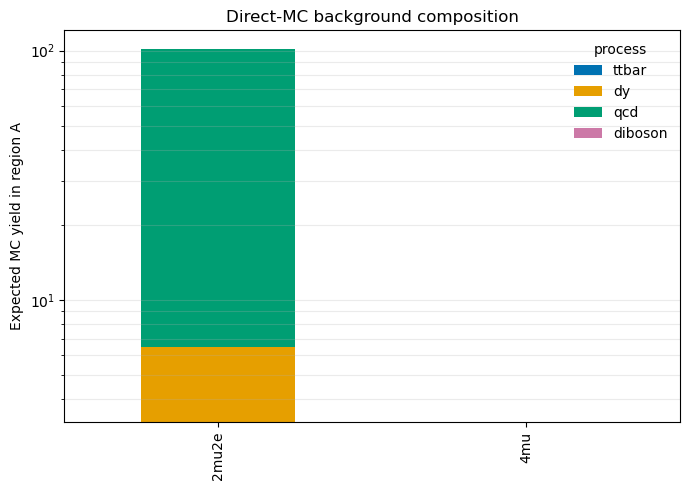

In [2]:
CFG={"2mu2e":("mulj_egmlj_iso","test_SR_2mu2e",(0.25,0.10)),
     "4mu":("mulj_mulj_iso","test_SR_4mu",(0.25,0.25))}
GROUPS={"ttbar":("TTJets",),"dy":("DYJetsToLL",),"qcd":("QCD_",),
        "diboson":("WW","WZ","ZZ")}
ORDER=tuple(GROUPS)

def get_hist(path,hname,channel):
    loaded=coffea.util.load(path); payload=loaded.get("out",loaded)[path.stem]
    h=payload["hists"][hname]
    return h[{"channel":channel}] if "channel" in h.axes.name else h

def group(name):
    found=[g for g,prefix in GROUPS.items() if name.startswith(prefix)]
    if len(found)!=1: raise ValueError(f"{name} maps to {found}")
    return found[0]

def yield_a(h,cuts):
    v=np.asarray(h.values(flow=True),float).copy()
    v[-2,:]+=v[-1,:]; v=v[:-1,:]; v[:,-2]+=v[:,-1]; v=v[1:,1:-1]
    x=np.asarray(h.axes[0].centers)[:,None]; y=np.asarray(h.axes[1].centers)[None,:]
    return float(v[(x<cuts[0]) & (y<cuts[1])].sum())

rows=[]
for channel,(hname,hchannel,cuts) in CFG.items():
    parts={g:[] for g in ORDER}
    for path in sorted(BKG_DIR.glob("*.coffea")):
        parts[group(path.stem)].append(get_hist(path,hname,hchannel))
    for process,hs in parts.items():
        total=hs[0].copy()
        for h in hs[1:]: total=total+h
        rows.append({"channel":channel,"process":process,"yield":yield_a(total,cuts)})
bkg=pd.DataFrame(rows)
if (bkg["yield"]<0).any(): raise ValueError("Negative MC rate")
bkg.to_csv(OUT/"mc_background_yields.csv",index=False)
background_table=bkg.pivot(index="channel",columns="process",values="yield").reindex(columns=ORDER)
display(background_table)
ax=background_table.plot.bar(stacked=True,figsize=(7,5),color=["#0072B2","#E69F00","#009E73","#CC79A7"])
ax.set_yscale("log"); ax.set_ylabel("Expected MC yield in region A"); ax.set_xlabel("")
ax.set_title("Direct-MC background composition"); ax.legend(title="process",frameon=False)
ax.grid(True,axis="y",which="both",alpha=.25); plt.tight_layout(); plt.show()

## 2. Signal grid and datacards

Only the normalized signal_A yield produced by notebook 08 is used. One card is written per signal point and channel, plus a statistically combined two-channel card.

In [3]:
signals=pd.read_csv(SIGNAL_INPUT)
KEYS=["mA_GeV","mZd_GeV","lxy_cm"]
if (signals.signal_A<0).any(): raise ValueError("Negative signal rate")
if not (signals.groupby(KEYS).topology.nunique()==2).all():
    raise ValueError("Each point needs both topologies")
blookup=bkg.pivot(index="channel",columns="process",values="yield")

def tag(ma,mzd,lxy):
    return f"mA{ma:g}_mZd{mzd:g}_Lxy{lxy:g}".replace(".","p")

def card_text(channels):
    bins=[]; procs=[]; ids=[]; rates=[]; obs=[]
    for ch,payload in channels.items():
        bin_name=f"ch_{ch}"
        obs.append(sum(payload[p] for p in ORDER))
        for i,p in enumerate(("signal",*ORDER)):
            bins.append(bin_name); procs.append(p); ids.append(i); rates.append(payload[p])
    return "\n".join([f"imax {len(channels)}",f"jmax {len(ORDER)}","kmax *","------------",
      "bin "+" ".join(f"ch_{ch}" for ch in channels),"observation "+" ".join(f"{x:.10g}" for x in obs),"------------",
      "bin "+" ".join(bins),"process "+" ".join(procs),"process "+" ".join(map(str,ids)),
      "rate "+" ".join(f"{x:.10g}" for x in rates),"------------",
      "lumi lnN "+" ".join("1.025" for x in rates),"* autoMCStats 0",""])

manifest=[]
for keys,frame in signals.groupby(KEYS,sort=True):
    ma,mzd,lxy=map(float,keys); base=tag(ma,mzd,lxy); sig=frame.set_index("topology").signal_A
    payload={}
    for ch in CFG:
        payload[ch]={"signal":float(sig[ch]),**{p:float(blookup.loc[ch,p]) for p in ORDER}}
        name=f"{base}_{ch}"; path=CARDS/f"{name}.txt"; path.write_text(card_text({ch:payload[ch]}))
        manifest.append([name,ch,ma,mzd,lxy,str(path)])
    name=f"{base}_combined"; path=CARDS/f"{name}.txt"; path.write_text(card_text(payload))
    manifest.append([name,"combined",ma,mzd,lxy,str(path)])
manifest=pd.DataFrame(manifest,columns=["tag","channel",*KEYS,"datacard"])
manifest["root_file"]=[str(ROOTS/f"higgsCombine.{t}.AsymptoticLimits.mH{int(m)}.root") for t,m in manifest[["tag","mA_GeV"]].itertuples(index=False)]
manifest.to_csv(OUT/"manifest.csv",index=False)
print("cards:",len(manifest)); print(Path(manifest.datacard.iloc[0]).read_text())

cards: 180
imax 1
jmax 4
kmax *
------------
bin ch_2mu2e
observation 101.5524082
------------
bin ch_2mu2e ch_2mu2e ch_2mu2e ch_2mu2e ch_2mu2e
process signal ttbar dy qcd diboson
process 0 1 2 3 4
rate 0.01267630388 0 6.496079064 95.05632917 0
------------
lumi lnN 1.025 1.025 1.025 1.025 1.025
* autoMCStats 0



## 3. Combine execution

The default adaptive range is used, with targeted rMax overrides for validated low-signal boundary failures. Start with the three-card smoke test, then switch RUN_SCOPE to full.

In [4]:
def run(row):
    if not (CMSSW/"src").is_dir(): raise FileNotFoundError(CMSSW)
    prefix=f'source /cvmfs/cms.cern.ch/cmsset_default.sh >/dev/null 2>&1; cd {CMSSW}/src; eval "$(scram runtime -sh)"; '
    rmax=f" --rMax {RMAX_OVERRIDES[row.tag]}" if row.tag in RMAX_OVERRIDES else ""
    cmd=prefix+f"cd {ROOTS}; combine -M AsymptoticLimits {Path(row.datacard).resolve()} -t -1 --expectSignal 0 -n .{row.tag} -m {int(row.mA_GeV)}{rmax}"
    r=subprocess.run(["bash","-lc",cmd],text=True,capture_output=True,timeout=1800)
    return {**row._asdict(),"returncode":r.returncode,"root_exists":r.returncode==0 and Path(row.root_file).is_file(),"stderr":r.stderr[-2000:]}

todo=manifest
if RUN_SCOPE=="smoke":
    first=manifest.iloc[0]; todo=manifest[np.logical_and.reduce([manifest[k].eq(first[k]) for k in KEYS])]
elif RUN_SCOPE!="full": raise ValueError(RUN_SCOPE)
if RUN_COMBINE:
    status=pd.DataFrame([run(r) for r in todo.itertuples(index=False)])
    status.to_csv(OUT/"run_status.csv",index=False); display(status[["tag","returncode","root_exists"]])
    for r in status[status.returncode!=0].itertuples(): print(r.tag,r.stderr)
else: print(f"{len(todo)} cards selected; RUN_COMBINE=False")

,tag,returncode,root_exists
0,mA200_mZd0p25_Lxy0p3_2mu2e,0,True
1,mA200_mZd0p25_Lxy0p3_4mu,0,True
2,mA200_mZd0p25_Lxy0p3_combined,0,True
3,mA200_mZd0p25_Lxy3_2mu2e,0,True
4,mA200_mZd0p25_Lxy3_4mu,0,True
...,...,...,...
175,mA1000_mZd5_Lxy150_4mu,0,True
176,mA1000_mZd5_Lxy150_combined,0,True
177,mA1000_mZd5_Lxy300_2mu2e,0,True
178,mA1000_mZd5_Lxy300_4mu,0,True


## 4. Parse complete ROOT files

Incomplete outputs are recorded and skipped, so one failed point cannot abort the scan.

In [5]:
Q={.025:"exp_m2",.16:"exp_m1",.5:"exp_median",.84:"exp_p1",.975:"exp_p2"}
def parse(path):
    with uproot.open(path) as f:
        q=np.asarray(f["limit"]["quantileExpected"].array()); v=np.asarray(f["limit"]["limit"].array())
    out={}
    for a,b in zip(q,v):
        if a<0: continue
        x=min(Q,key=lambda z:abs(z-a))
        if abs(x-a)<.01: out[Q[x]]=float(b)
    missing=set(Q.values())-out.keys()
    if missing: raise ValueError(f"missing {sorted(missing)}, quantiles={q.tolist()}")
    return out

good=[]; bad=[]
for r in manifest.itertuples(index=False):
    if not Path(r.root_file).is_file(): continue
    try: good.append({**r._asdict(),**parse(r.root_file)})
    except Exception as e: bad.append({**r._asdict(),"error":repr(e)})
limits=pd.DataFrame(good); failures=pd.DataFrame(bad)
limits.to_csv(OUT/"expected_limits.csv",index=False); failures.to_csv(OUT/"parse_failures.csv",index=False)
print("complete:",len(limits),"failed:",len(failures))
if len(limits): display(limits.head())
if len(failures): display(failures[["tag","error"]])

complete: 180 failed: 0


,tag,channel,mA_GeV,mZd_GeV,lxy_cm,datacard,root_file,exp_m2,exp_m1,exp_median,exp_p1,exp_p2
0,mA200_mZd0p25_Lxy0p3_2mu2e,2mu2e,200.0,0.25,0.3,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,907.031250,1218.245850,1720.000,2453.591309,3375.534912
1,mA200_mZd0p25_Lxy0p3_4mu,4mu,200.0,0.25,0.3,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,230.156250,325.934814,491.000,763.043457,1145.161133
2,mA200_mZd0p25_Lxy0p3_combined,combined,200.0,0.25,0.3,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,222.554688,312.311951,467.000,716.438599,1057.264282
3,mA200_mZd0p25_Lxy3_2mu2e,2mu2e,200.0,0.25,3.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,90.816406,122.468719,173.500,247.498886,338.309082
4,mA200_mZd0p25_Lxy3_4mu,4mu,200.0,0.25,3.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,18.808594,26.635712,40.125,62.356655,93.583687


## 5. Smoke-point visualization

For one physical point, compare the expected limit bands for 2mu2e, 4mu, and their combination. This remains useful before a full scan provides enough points for continuous curves.

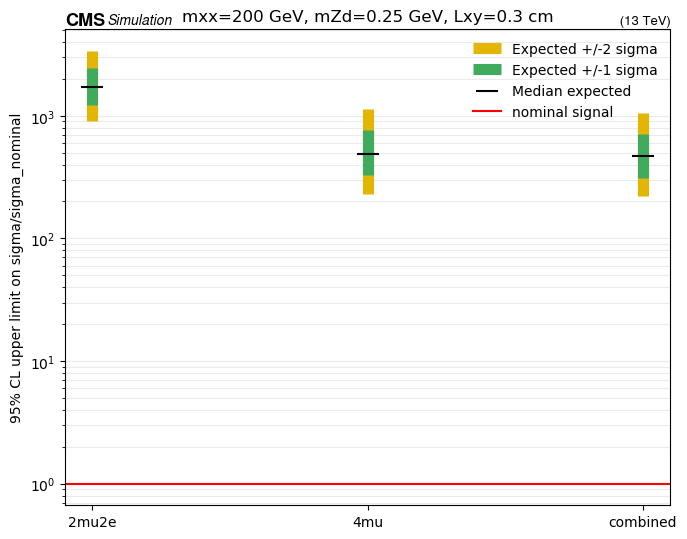

In [6]:
if len(limits):
    first=limits.iloc[0]; point=limits[np.logical_and.reduce([limits[k].eq(first[k]) for k in KEYS])].copy()
    point["channel"]=pd.Categorical(point.channel,["2mu2e","4mu","combined"],ordered=True)
    point=point.sort_values("channel"); x=np.arange(len(point))
    fig,ax=plt.subplots(figsize=(7,5.5))
    ax.vlines(x,point.exp_m2,point.exp_p2,color="#E3B505",linewidth=8,label="Expected +/-2 sigma")
    ax.vlines(x,point.exp_m1,point.exp_p1,color="#41AB5D",linewidth=8,label="Expected +/-1 sigma")
    ax.scatter(x,point.exp_median,color="black",marker="_",s=250,zorder=3,label="Median expected")
    ax.axhline(1,color="red",linewidth=1.5,label="nominal signal")
    ax.set_xticks(x,point.channel.astype(str)); ax.set_yscale("log")
    ax.set_ylabel("95% CL upper limit on sigma/sigma_nominal")
    ax.set_title(f"mxx={first.mA_GeV:g} GeV, mZd={first.mZd_GeV:g} GeV, Lxy={first.lxy_cm:g} cm")
    ax.grid(True,axis="y",which="both",alpha=.25); ax.legend(frameon=False); hep.cms.label(data=False,com=13,ax=ax)
    fig.tight_layout(); fig.savefig(PLOTS/"smoke_point_summary.png",dpi=180,bbox_inches="tight"); plt.show(); plt.close(fig)
else: print("No complete ROOT files available for the smoke-point plot")

## 6. Expected limit scans

Plots compare 2mu2e, 4mu, and combined medians. Yellow and green bands are shown for the combined result.

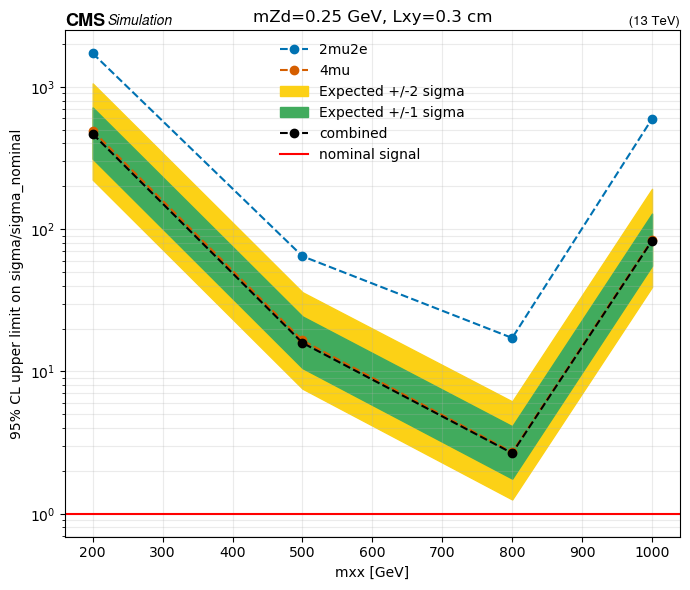

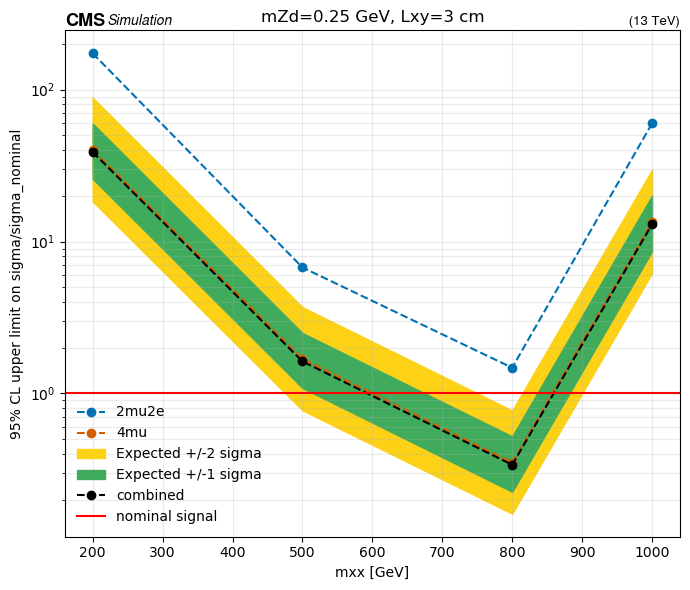

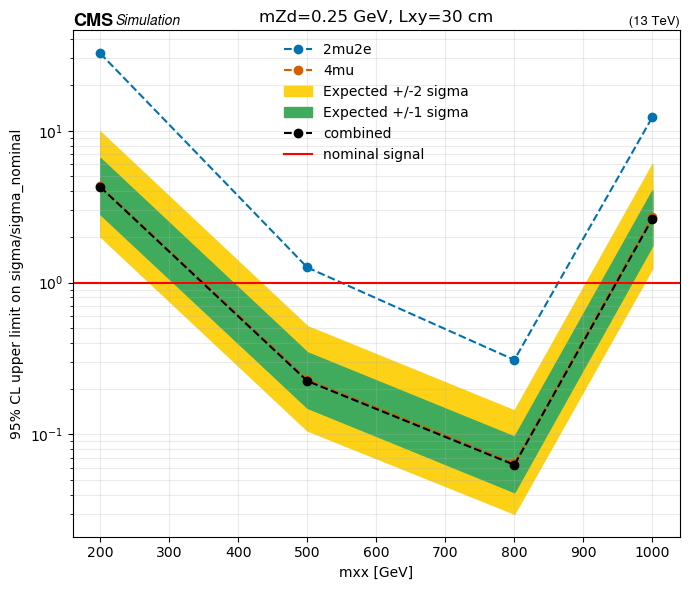

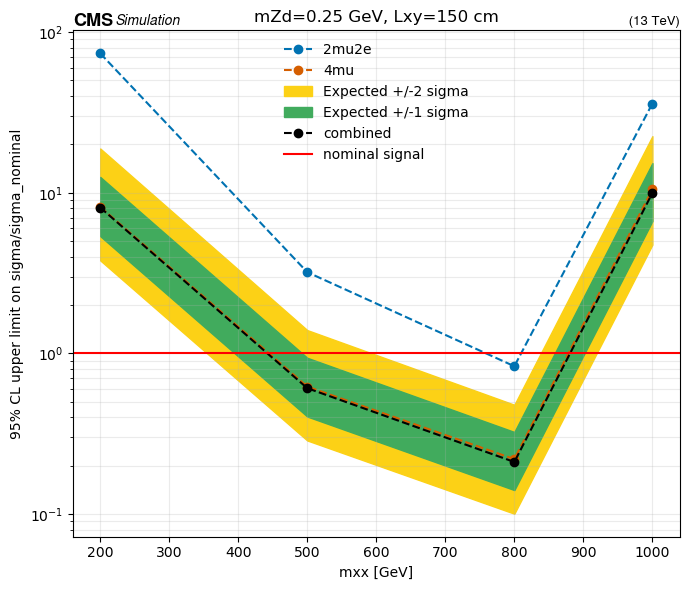

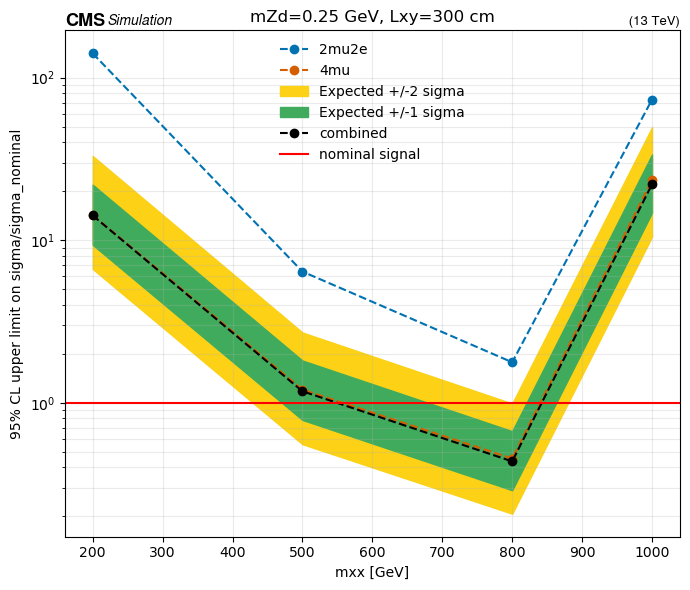

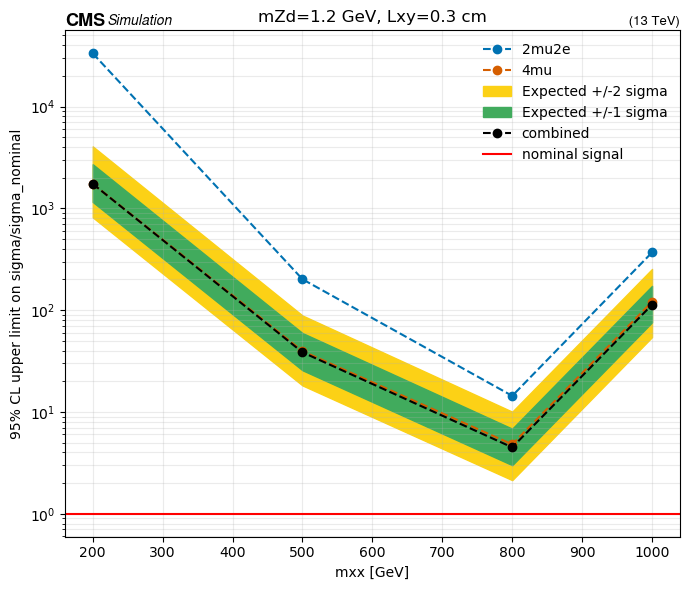

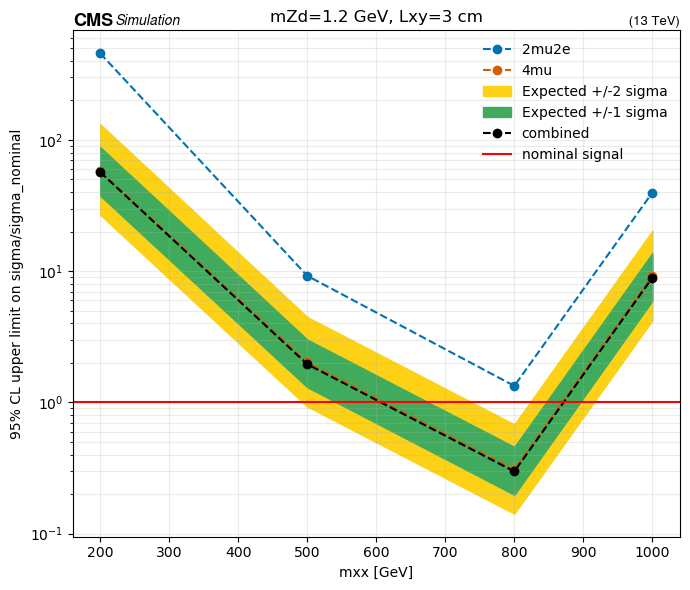

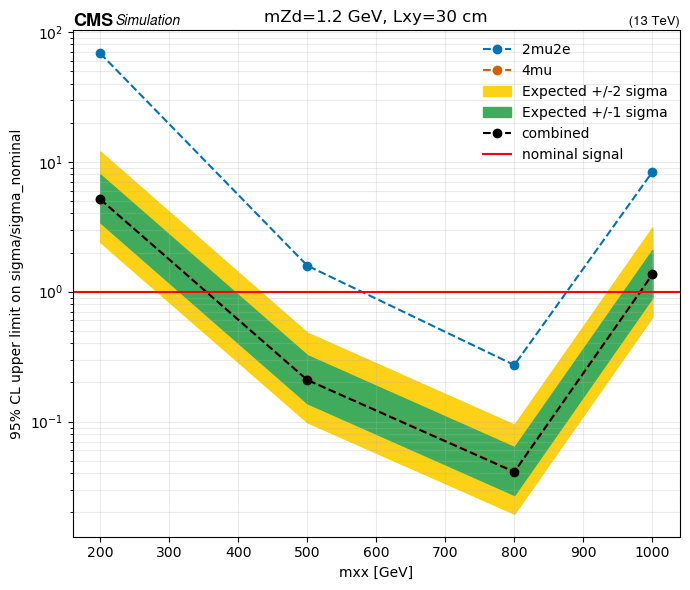

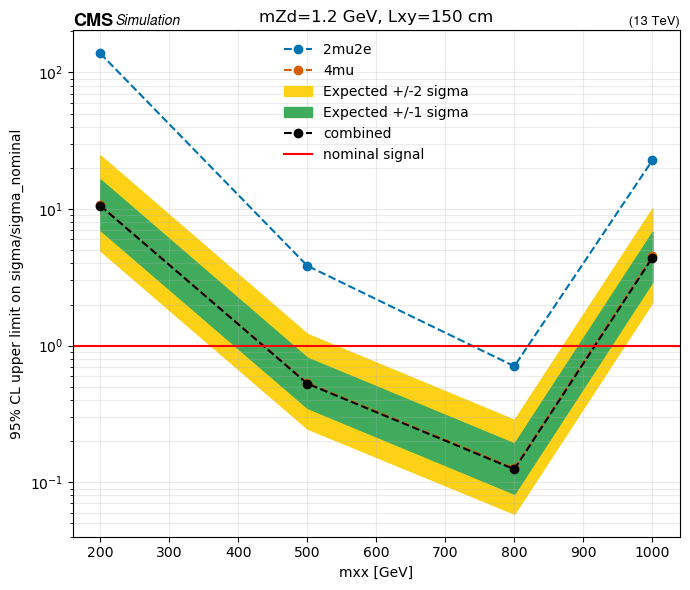

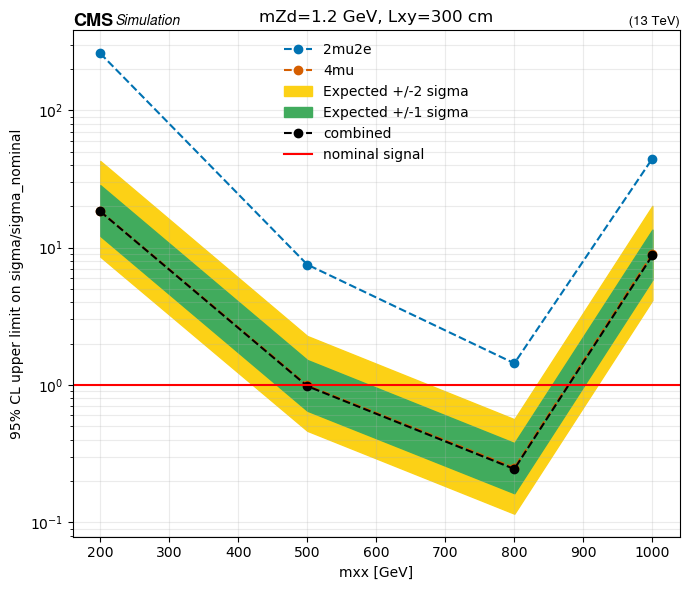

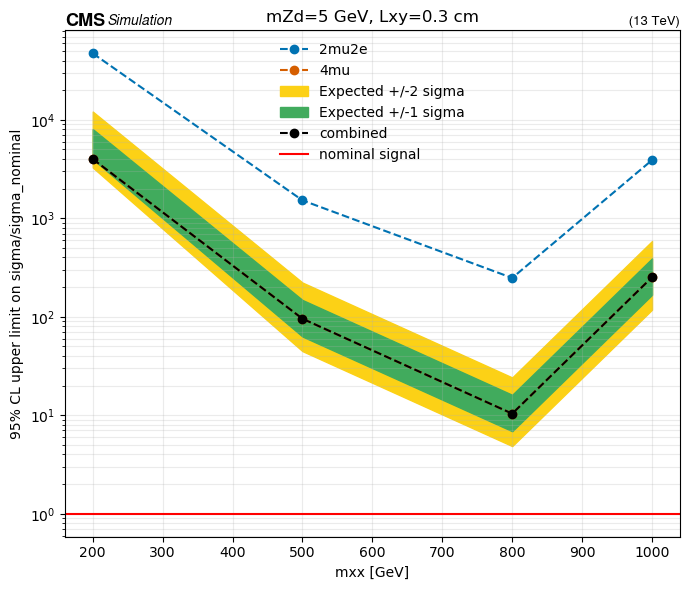

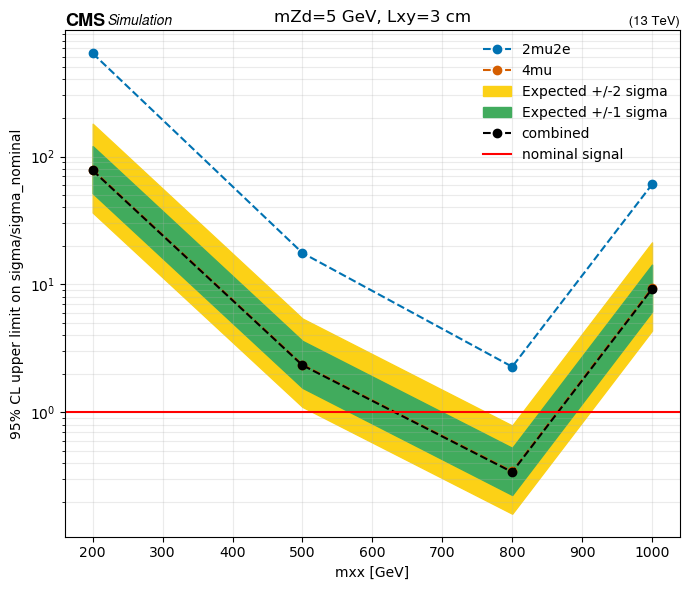

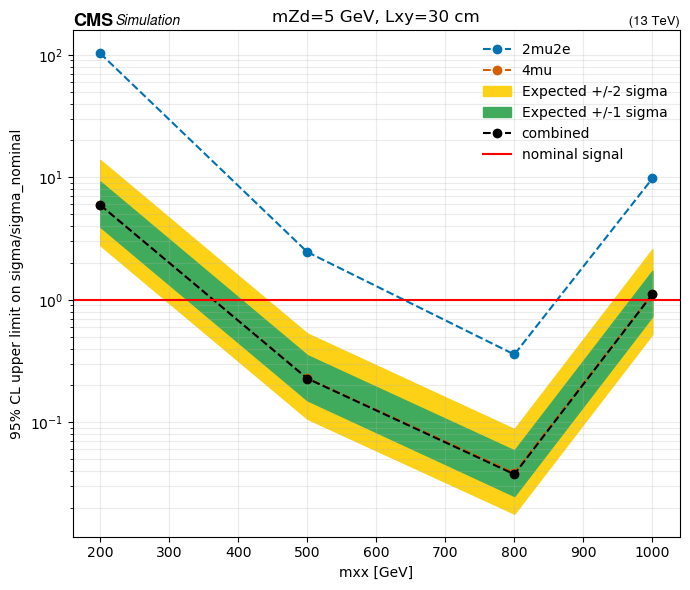

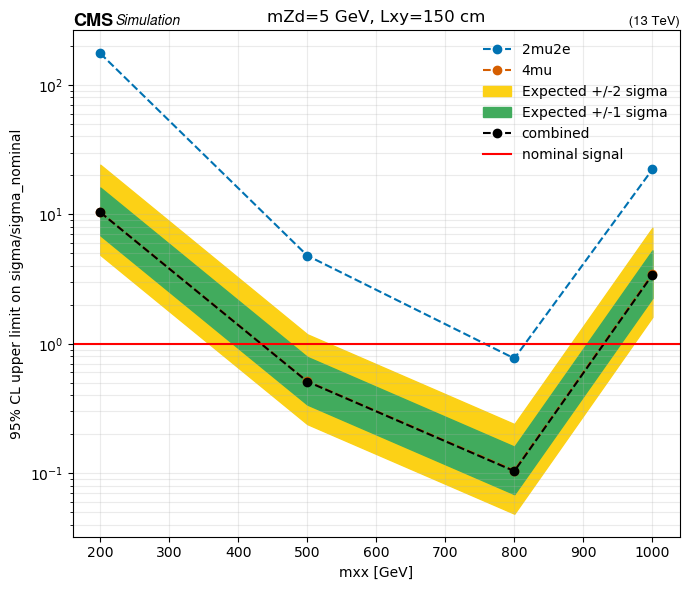

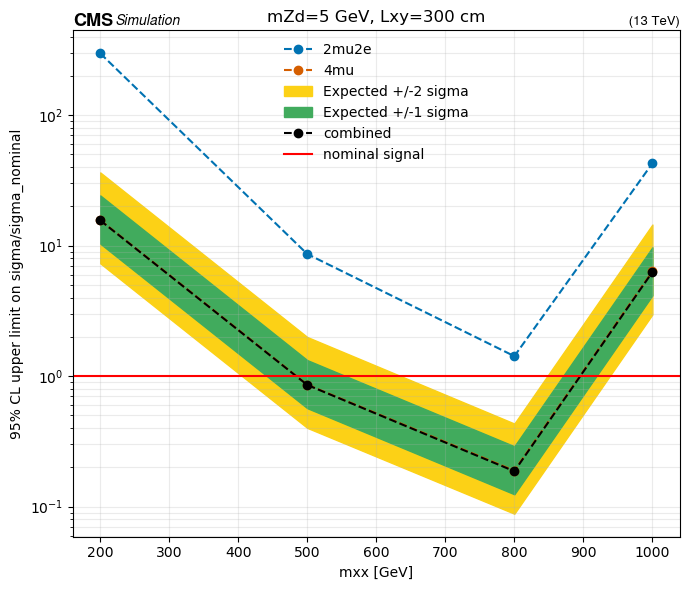

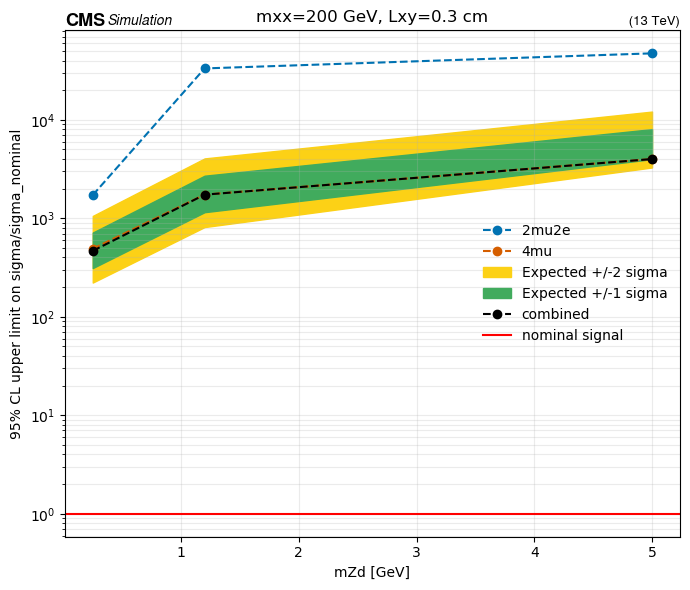

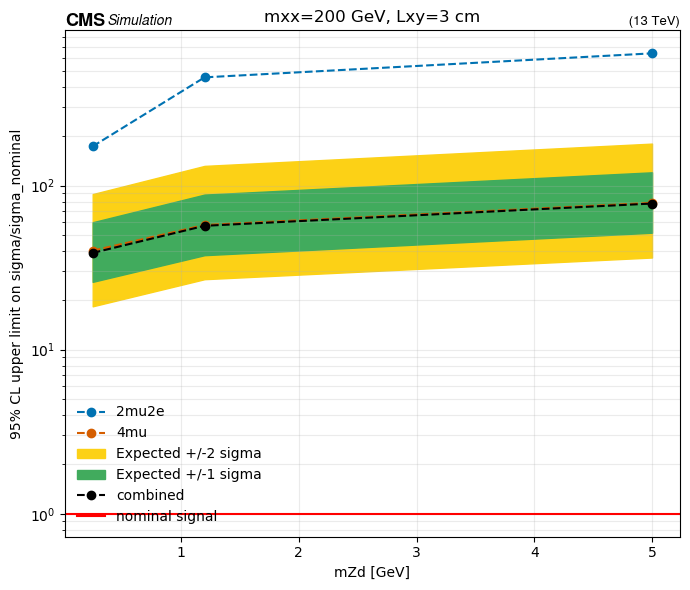

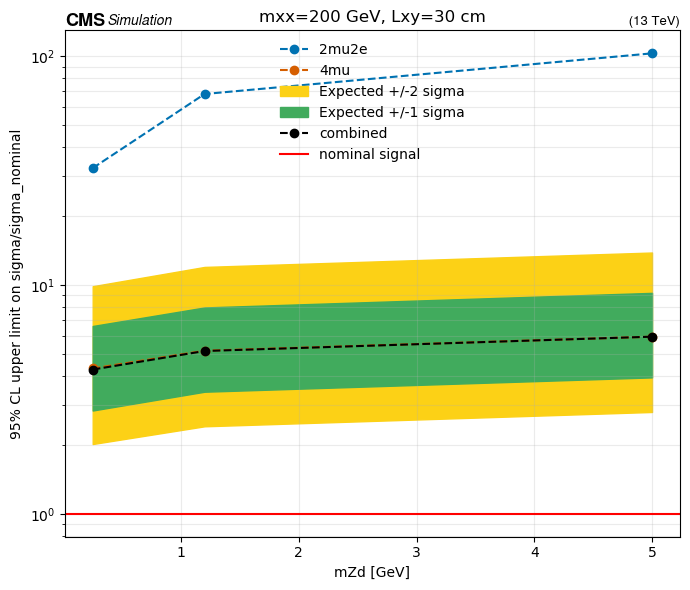

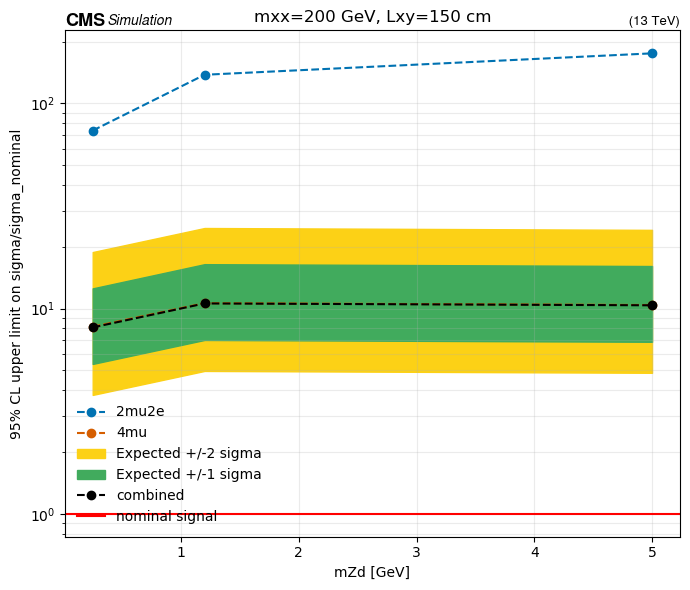

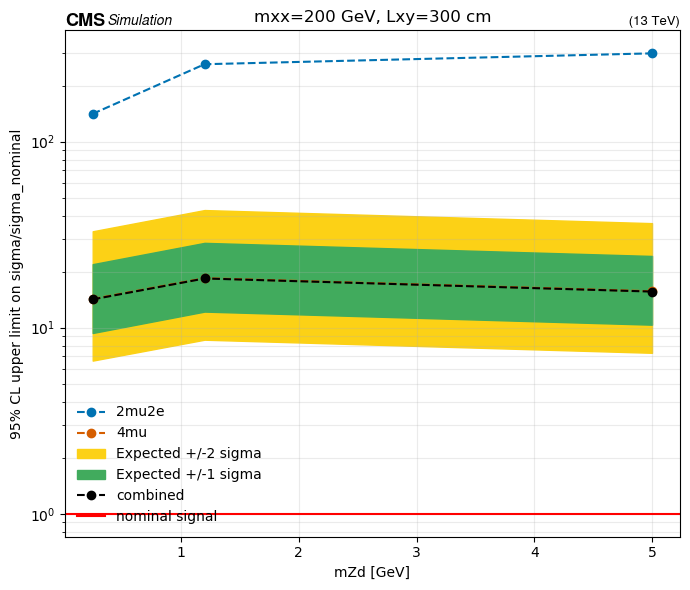

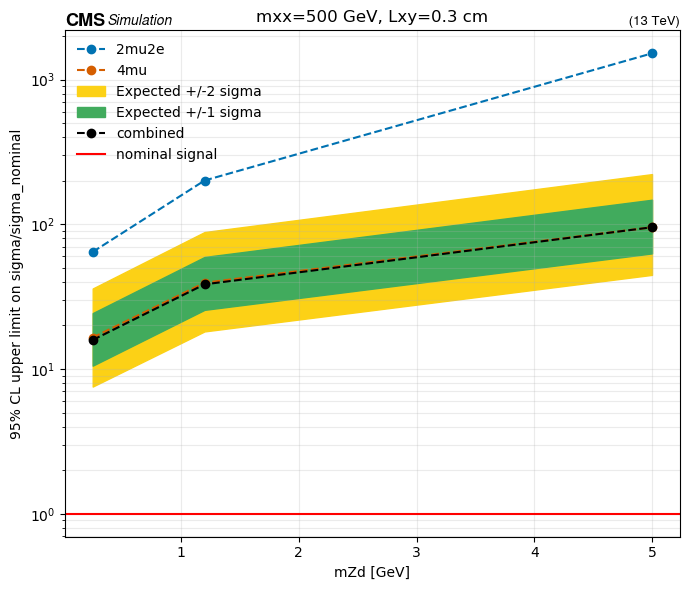

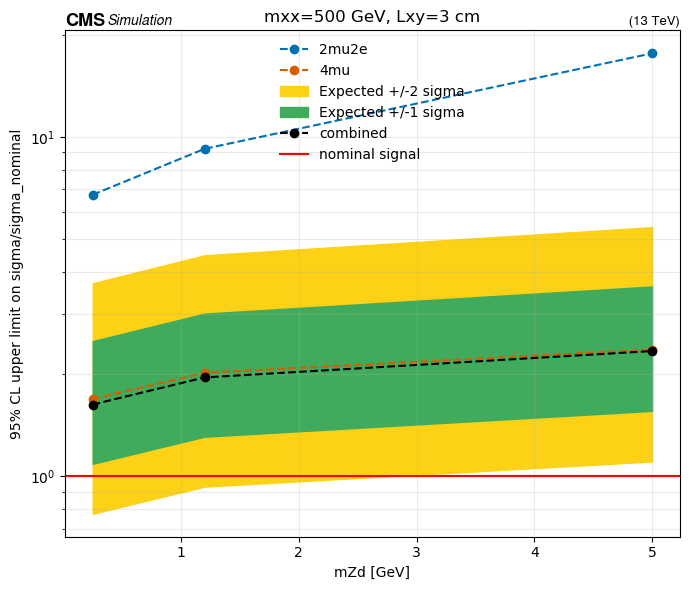

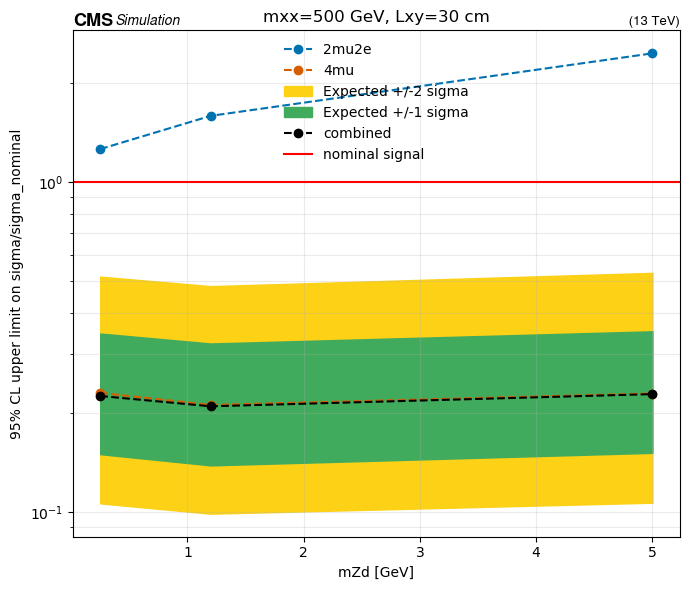

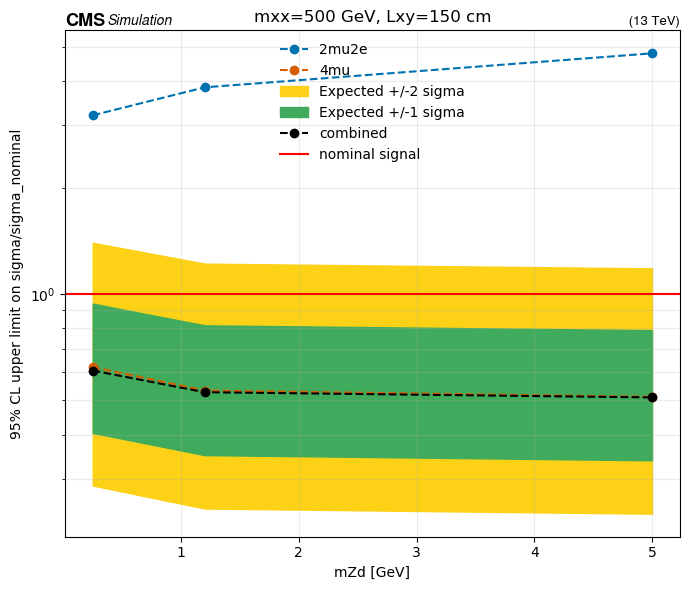

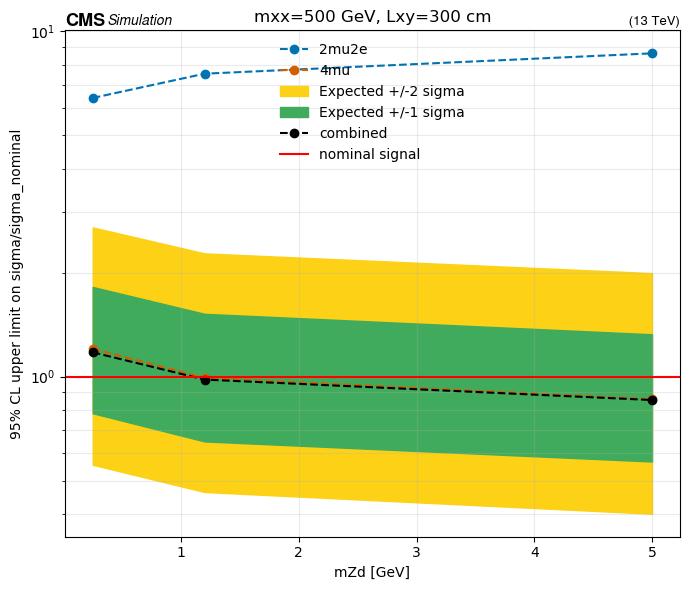

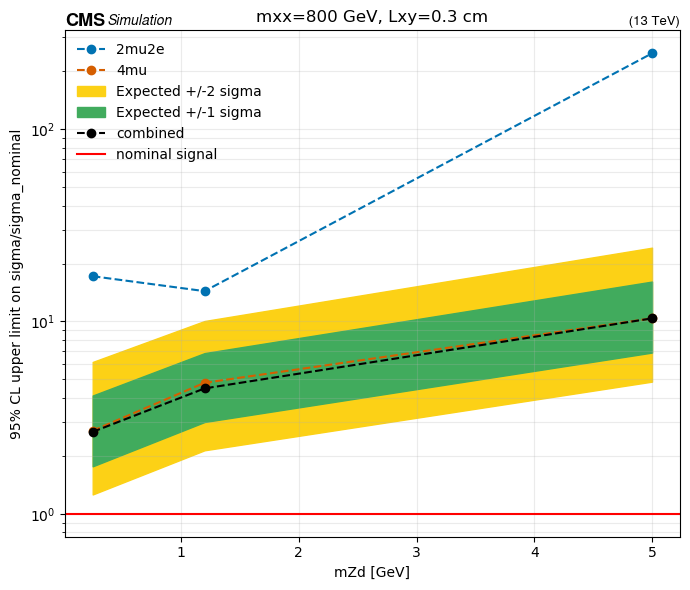

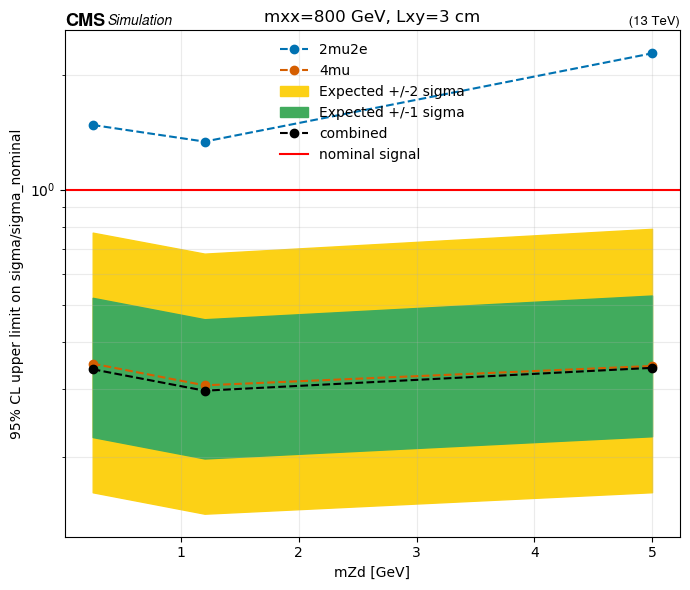

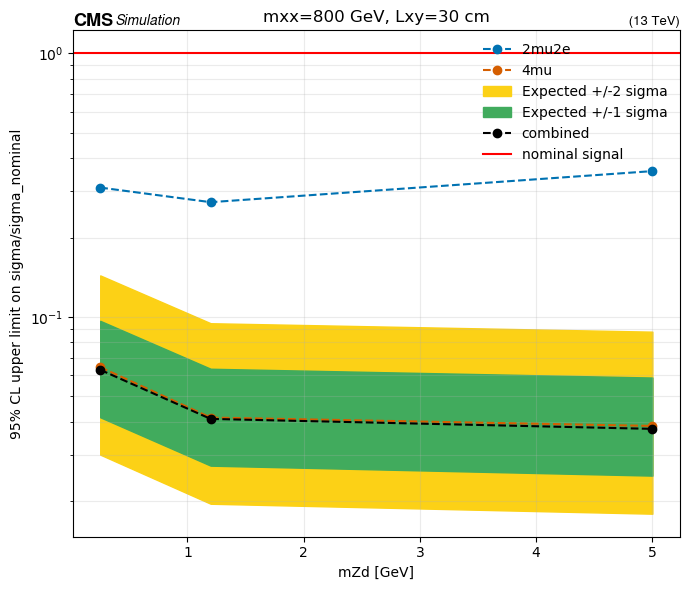

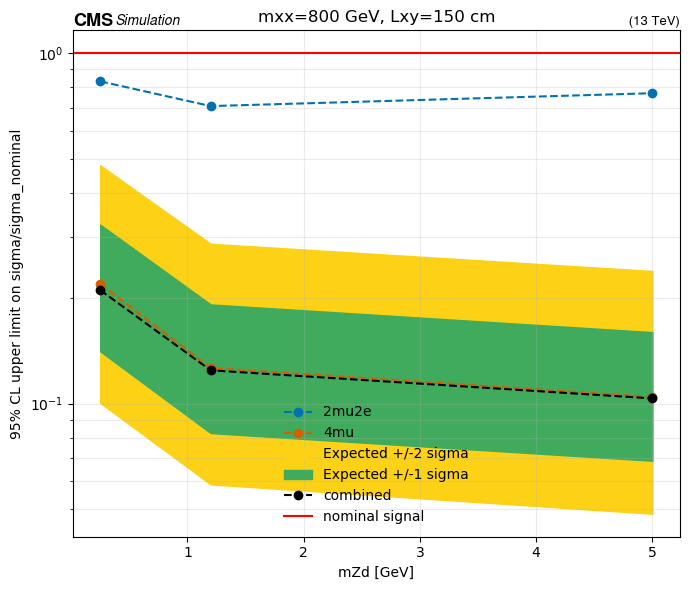

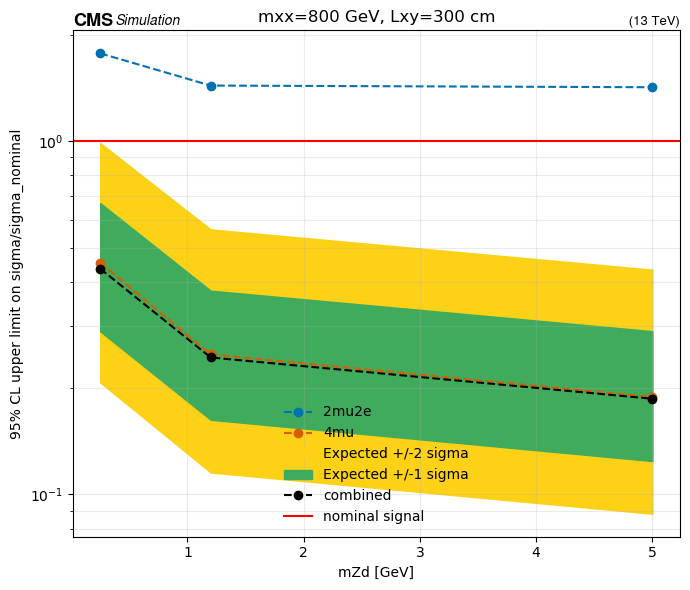

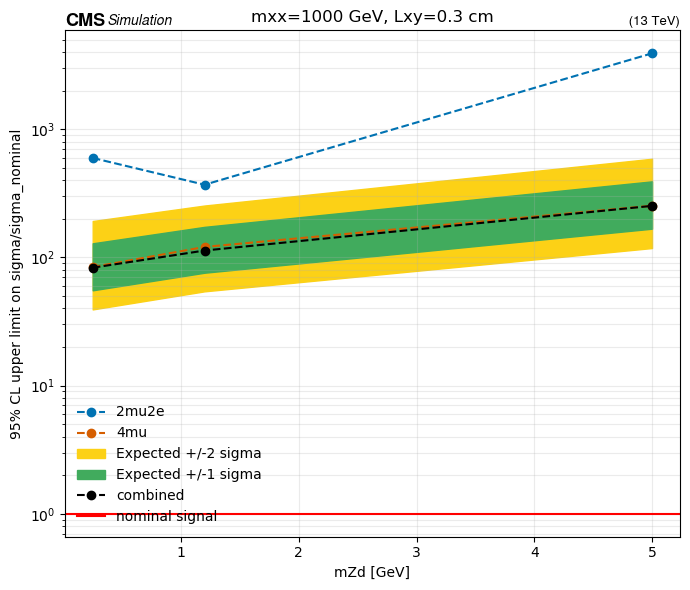

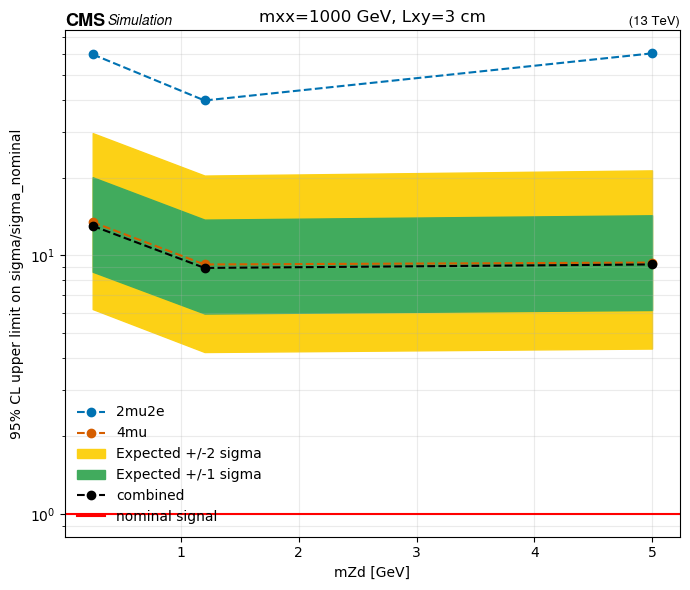

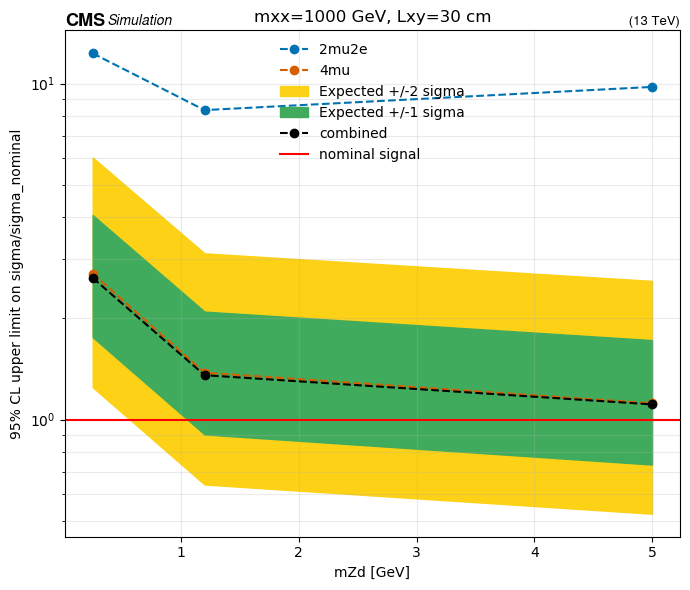

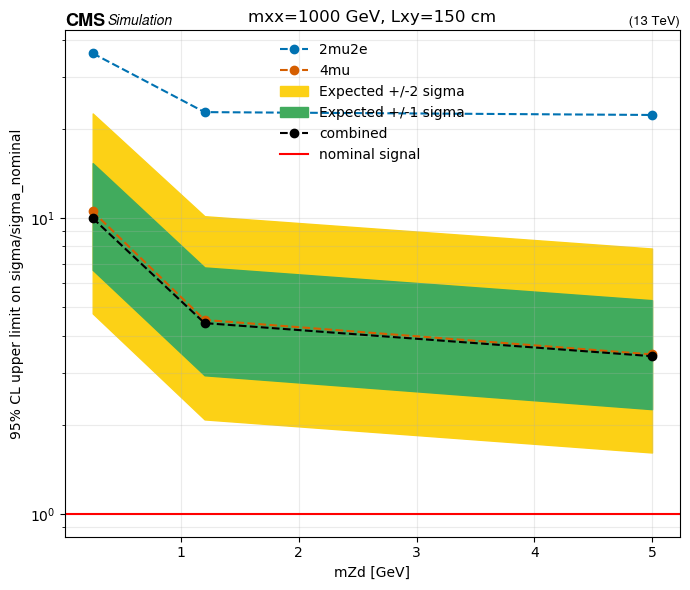

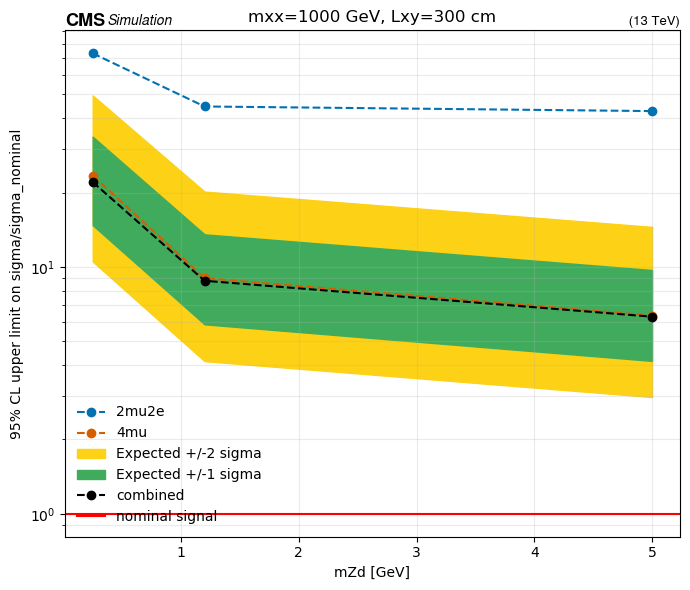

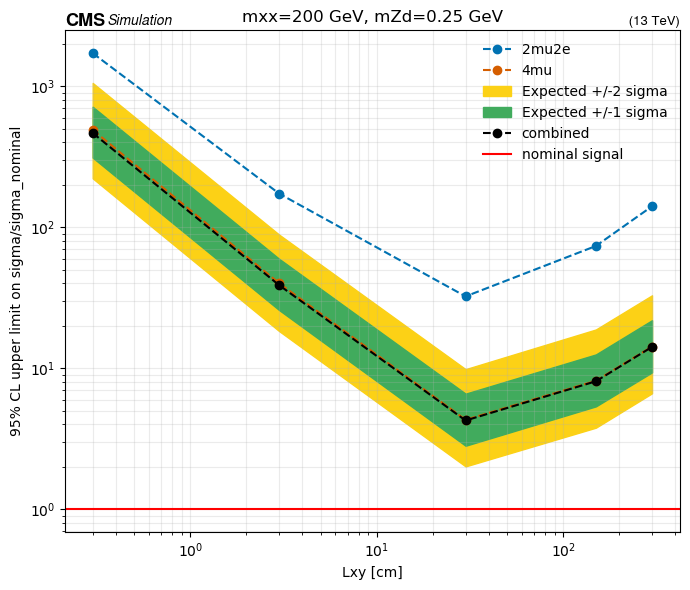

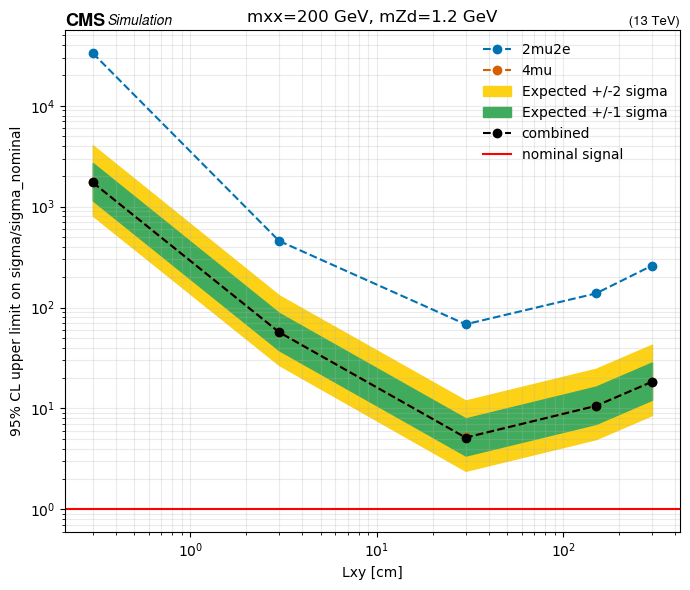

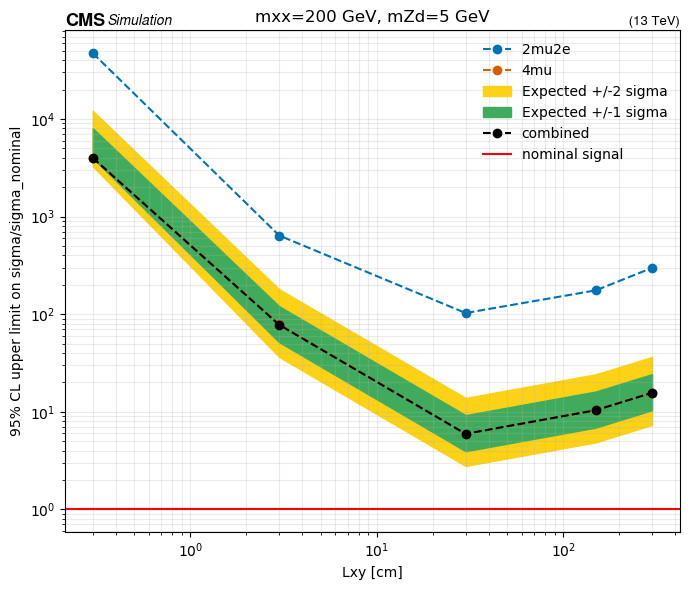

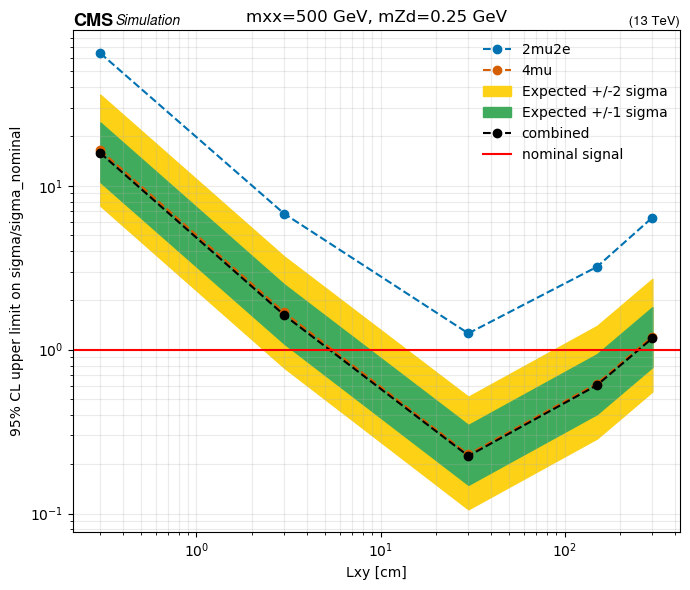

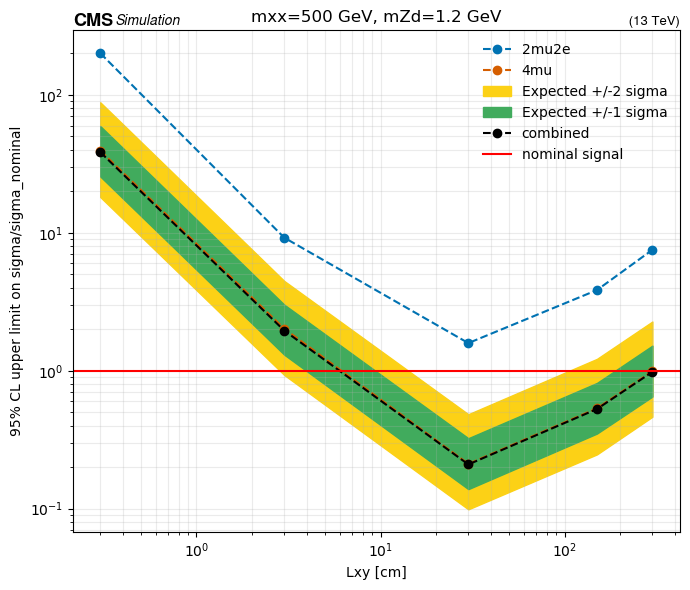

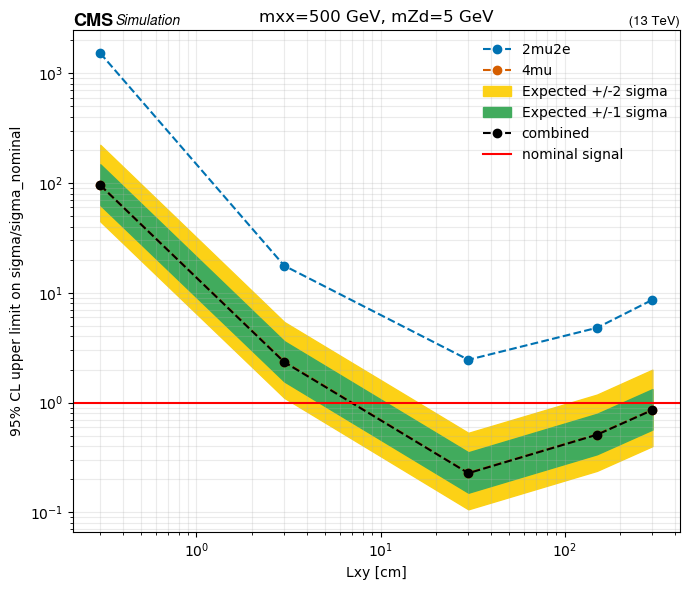

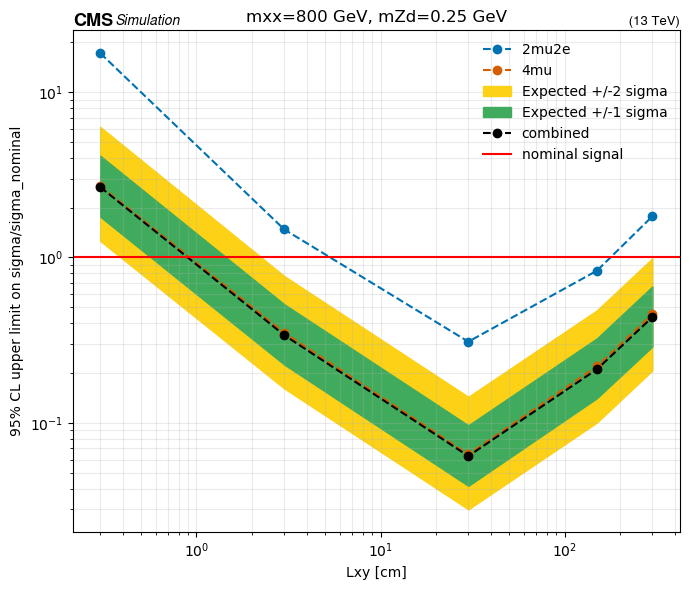

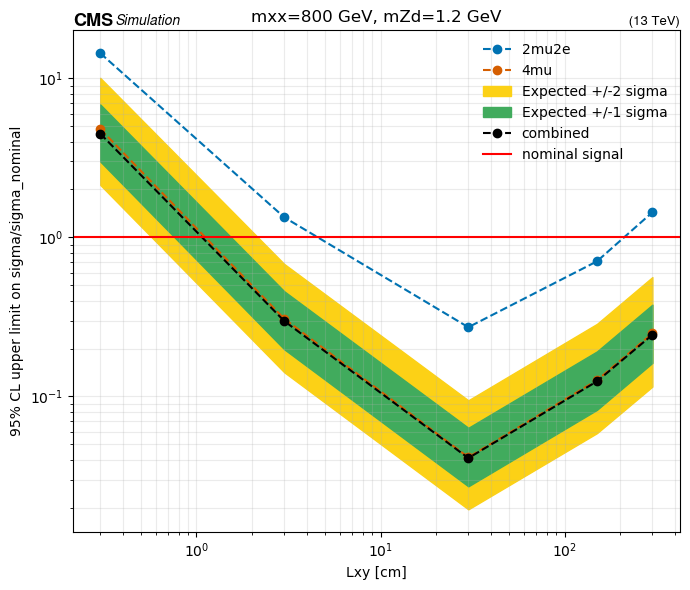

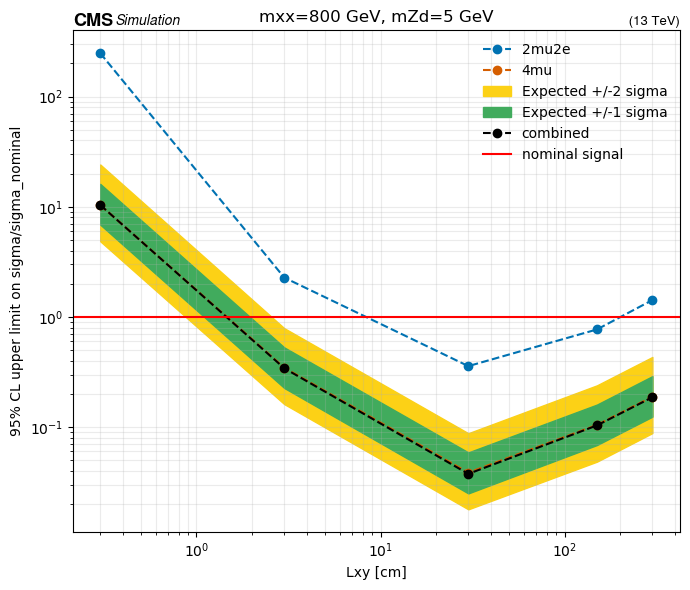

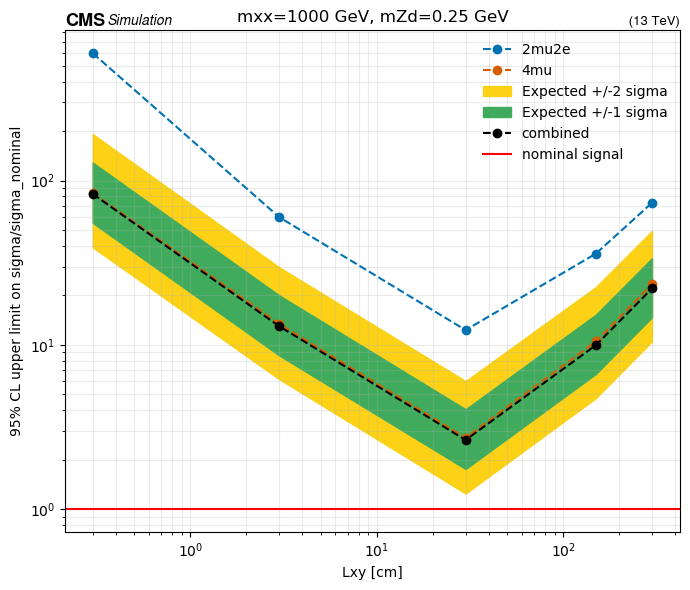

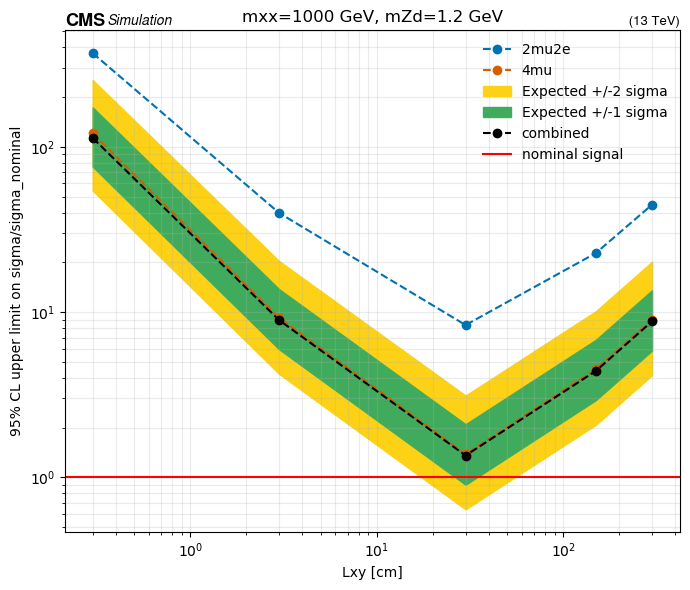

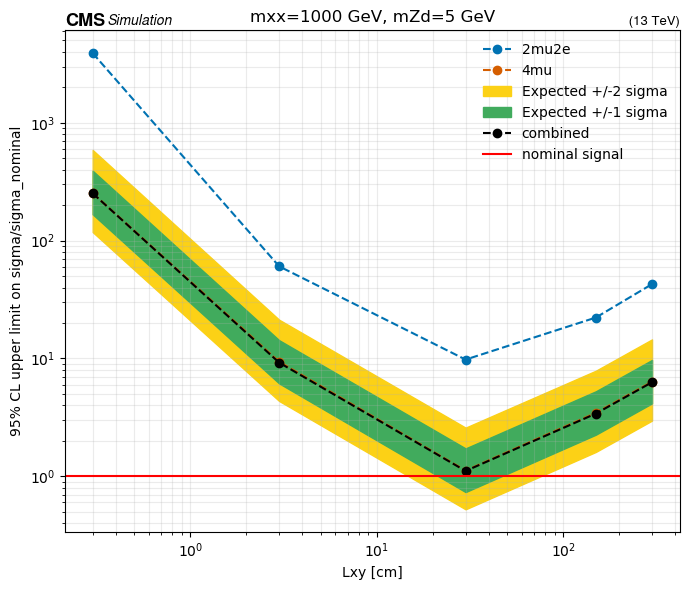

plots: 47


In [7]:
def plot_scan(frame,x,xlabel,title,path,logx=False):
    fig,ax=plt.subplots(figsize=(7,6)); colors={"2mu2e":"#0072B2","4mu":"#D55E00","combined":"black"}
    for ch in colors:
        q=frame[frame.channel==ch].sort_values(x)
        if len(q)<2: continue
        xv=q[x].to_numpy(float)
        if ch=="combined":
            ax.fill_between(xv,q.exp_m2,q.exp_p2,color="#FCD116",label="Expected +/-2 sigma")
            ax.fill_between(xv,q.exp_m1,q.exp_p1,color="#41AB5D",label="Expected +/-1 sigma")
        ax.plot(xv,q.exp_median,"o--",color=colors[ch],label=ch)
    if not ax.lines: plt.close(fig); return 0
    ax.axhline(1,color="red",label="nominal signal"); ax.set_yscale("log")
    if logx: ax.set_xscale("log")
    ax.set(xlabel=xlabel,ylabel="95% CL upper limit on sigma/sigma_nominal",title=title)
    ax.grid(True,which="both",alpha=.25); ax.legend(frameon=False); hep.cms.label(data=False,com=13,ax=ax)
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show(); plt.close(fig); return 1

nplots=0
if len(limits):
    for (mzd,lxy),f in limits.groupby(["mZd_GeV","lxy_cm"]):
        nplots+=plot_scan(f,"mA_GeV","mxx [GeV]",f"mZd={mzd:g} GeV, Lxy={lxy:g} cm",PLOTS/f"mA_mZd{mzd:g}_Lxy{lxy:g}.png")
    for (ma,lxy),f in limits.groupby(["mA_GeV","lxy_cm"]):
        nplots+=plot_scan(f,"mZd_GeV","mZd [GeV]",f"mxx={ma:g} GeV, Lxy={lxy:g} cm",PLOTS/f"mZd_mA{ma:g}_Lxy{lxy:g}.png")
    for (ma,mzd),f in limits.groupby(["mA_GeV","mZd_GeV"]):
        nplots+=plot_scan(f,"lxy_cm","Lxy [cm]",f"mxx={ma:g} GeV, mZd={mzd:g} GeV",PLOTS/f"Lxy_mA{ma:g}_mZd{mzd:g}.png",True)
print("plots:",nplots)

## Validation order

Set RUN_COMBINE=True while keeping RUN_SCOPE=smoke. Require three successful cards and three complete ROOT files. Then switch RUN_SCOPE to full. This direct-MC result is a baseline; the ABCD likelihood should be reintroduced and validated separately.